# Numpy
## Learning Objectives: 
-   Read tabular data from a file into a program.
-   Select individual values and subsections from data.
-   Perform operations on arrays of data.

## Writing a notebook
### Some more setting up
Create a directory for the intro to Python  module
```
cd ~/work/classes/GPGN268/coursework-du
mkdir -p ds00-python-intro/data
mkdir -p ds00-python-intro/notebooks
```
Getting the data for today's class
```
cd ~/work/classes/GPGN268/
git clone git@github.com:GPGN268/GPGN268-CORE.git
cd GPGN268-CORE
git pull
```

```
ls -RF
```

```
cd intro-python/data
ls -F
```

```
cp meteo*.txt ~/work/classes/GPGN268/coursework-du/ds00-python-intro/data
```

Now let's navigate to our newly created directory 
```
cd ~/work/classes/GPGN268/coursework-du/ds00-python-intro
```
And launch VSCode. If you are on Windows, make sure VSCode is opened connected to your WSL instance.

### Loading data into Python
First lets add a Markdown header so we know what this notebook is about.
``` markdown
# GPGN268 - Numpy and basics plotting
**Author:** Ryan Du

This notebook uses meteorological data from the Denver water department to introduce basic Python concepts.

```

We would like to process the Denver meteorological data using Python. But what is actually in these files? Let's use the terminal (or text editor) to take a look at the files using an additional tab  in VSCode. It looks like these files have numbers that are organized in columns and rows and separated by some white spaces.

To begin processing the meteorological data, we need to load it into Python. We can do that using a library called [NumPy](https://numpy.org/), which stands for Numerical Python. In general, you should use this library when you want to manipulate lots of numbers, especially if you have matrices or arrays. 

We will also need matplotlib, which is how to make common plots in python.

To tell Python that we’d like to start using NumPy and matplotlib, we need to import it:

In [31]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

Importing a library is like getting a piece of lab equipment out of a storage locker and setting it up on the bench. Libraries provide additional functionality to the basic Python package, much like a new piece of equipment adds functionality to a lab space. Just like in the lab, importing too many libraries can sometimes complicate and slow down your programs - so we only import what we need for each program.

Once we’ve imported the library, we can ask the library to read our data file for us:

In [3]:
# Load max temperature data into a numpy array.
# According to the README this corresponds to monthly maximum temperatures
# from 2000 to 2022 at the Dever Water Department meteorological station.
tmax = np.loadtxt(fname='../data/meteo_denver_tmax_2000_2022.txt', delimiter='\t')

The expression `numpy.loadtxt(...)` is a [function call](https://swcarpentry.github.io/python-novice-inflammation/reference.html#function-call) that asks Python to run the [function](https://swcarpentry.github.io/python-novice-inflammation/reference.html#function) `loadtxt` which belongs to the `numpy` library. The dot notation in Python is used most of all as an object attribute/property specifier or for invoking its method. `object.property` will give you the object.property value, `object_name.method()` will invoke on object_name method.

As an example, Mines Stadium is the stadium that belongs to Mines. We could use the dot notation to write  `mines.stadium`, just as `loadtxt` is a function that belongs to the `numpy` library.

`numpy.loadtxt` has two [parameters](https://swcarpentry.github.io/python-novice-inflammation/reference.html#parameter): the name of the file we want to read and the [delimiter](https://swcarpentry.github.io/python-novice-inflammation/reference.html#delimiter) that separates values on a line. These both need to be character strings (or [strings](https://swcarpentry.github.io/python-novice-inflammation/reference.html#string) for short), so we put them in quotes.

Since we haven’t told it to do anything else with the function’s output, the [notebook](https://swcarpentry.github.io/python-novice-inflammation/reference.html#notebook) displays it. In this case, that output is the data we just loaded. By default, only a few rows and columns are shown (with `...` to omit elements when displaying big arrays). Note that, to save space when displaying NumPy arrays, Python does not show us trailing zeros, so `1.0` becomes `1.`.

Our call to `numpy.loadtxt` read our file but didn’t save the data in memory. To do that, we need to assign the array to a variable. In a similar manner to how we assign a single value to a variable, we can also assign an array of values to a variable using the same syntax. Let’s re-run `numpy.loadtxt` and save the returned data:

In [4]:
tmax = np.loadtxt(fname='../data/meteo_denver_tmax_2000_2022.txt', delimiter='\t')

This statement doesn’t produce any output because we’ve assigned the output to the variable `data`. If we want to check that the data have been loaded, we can type the variable’s name:

In [5]:
tmax

array([[50.9, 56.4, 57.5, 69.3, 78.2, 86. , 94.7, 93. , 81.9, 67.5, 46.2,
        46.1],
       [48.2, 45.4, 54.8, 65.8, 73.8, 87.3, 95.3, 90.6, 86. , 69.7, 61.7,
        50.2],
       [47.7, 51.8, 51.7, 69.7, 73.1, 90.4, 96. , 90.3, 82. , 63.3, 52.3,
        50.6],
       [54.7, 44.7, 54.6, 67.9, 73.8, 80.1, 96.7, 92.4, 79.3, 74.3, 51.4,
        50.2],
       [50.4, 46.5, 63.3, 63.5, 76.7, 80.8, 88.4, 85.9, 80.7, 67.4, 53.4,
        47.7],
       [49.2, 51.2, 55.4, 62.5, 73.8, 84.3, 95.8, 88.2, 83.7, 68.9, 60.3,
        45.2],
       [54.5, 47.8, 53.5, 68.9, 74.9, 87.1, 88. , 83.8, 72. , 60.8, 50. ,
        40.2],
       [30.6, 40.8, 58.5, 61.7, 72.5, 86.5, 92.2, 90.9, 79.5, 66.3, 53.8,
        38.9],
       [40.1, 48.6, 54.8, 63. , 72.5, 85. , 93.9, 86.7, 78.5, 67.7, 64.5,
        44.6],
       [52. , 56.5, 60.5, 61.2, 73.7, 80.6, 87. , 88.4, 79.7, 57.5, 59.5,
        41.3],
       [48.5, 42.8, 56.3, 64.7, 69.9, 86.1, 91.7, 92.3, 86.5, 71.8, 55.8,
        52. ],
       [46.3, 45.5, 6

Now that the data are in memory, we can manipulate them. First, let’s ask what [type](https://swcarpentry.github.io/python-novice-inflammation/reference.html#type) of thing `data` refers to:

In [6]:
type(tmax)

numpy.ndarray

The output tells us that data currently refers to an N-dimensional array, the functionality for which is provided by the NumPy library. These data correspond to arthritis patients’ inflammation. The rows are the individual patients, and the columns are their daily inflammation measurements.

### Data Type
A Numpy array contains one or more elements of the same type. The type function will only tell you that a variable is a NumPy array but won’t tell you the type of thing inside the array. We can find out the type of the data contained in the NumPy array.

In [7]:
tmax.dtype

dtype('float64')

This tells us that the NumPy array’s elements are floating-point numbers.

With the following command, we can see the array’s shape:

In [8]:
print(tmax.shape)

(23, 12)


The output tells us that the `tmax` array variable contains 23 rows and 12 columns. When we created the variable `tmax` to store our temperature data, we did not only create the array; we also created information about the array, called [members](https://swcarpentry.github.io/python-novice-inflammation/reference.html#member) or attributes. This extra information describes `tmax` in the same way an adjective describes a noun. `tmax.shape` is an attribute of `tmax` which describes the dimensions of `tmax`. We use the same dotted notation for the attributes of variables that we use for the functions in libraries because they have the same part-and-whole relationship.

If we want to get a single number from the array, we must provide an [index](https://swcarpentry.github.io/python-novice-inflammation/reference.html#index) in square brackets after the variable name, just as we do in math when referring to an element of a matrix. Our inflammation data has two dimensions, so we will need to use two indices to refer to one specific value:

In [9]:
print('first value in tmax:', tmax[0, 0])

first value in tmax: 50.9


In [10]:
print('middle value in tmax:', tmax[11, 6])

middle value in tmax: 92.7


The expression `tmax[11, 6]` accesses the element at row 11, column 6. While this expression may not surprise you, `tmax[0, 0]` might. Programming languages like Fortran, MATLAB and R start counting at 1 because that’s what human beings have done for thousands of years. Languages in the C family (including C++, Java, Perl, and Python) count from 0 because it represents an offset from the first value in the array (the second value is offset by one index from the first value). This is closer to the way that computers represent arrays (if you are interested in the historical reasons behind counting indices from zero, you can read [Mike Hoye’s blog post](http://exple.tive.org/blarg/2013/10/22/citation-needed/)). As a result, if we have an M×N array in Python, its indices go from 0 to M-1 on the first axis and 0 to N-1 on the second. It takes a bit of getting used to, but one way to remember the rule is that the index is how many steps we have to take from the start to get the item we want.

### Slicing data

An index like `[11, 6]` selects a single element of an array, but we can select whole sections as well. For example, we can select the first ten days (columns) of values for the first four patients (rows) like this:

In [11]:
tmax[0:4, 0:6]

array([[50.9, 56.4, 57.5, 69.3, 78.2, 86. ],
       [48.2, 45.4, 54.8, 65.8, 73.8, 87.3],
       [47.7, 51.8, 51.7, 69.7, 73.1, 90.4],
       [54.7, 44.7, 54.6, 67.9, 73.8, 80.1]])

The [slice](https://swcarpentry.github.io/python-novice-inflammation/reference.html#slice) `0:4` means, “Start at index 0 and go up to, but not including, index 4”. Again, the up-to-but-not-including takes a bit of getting used to, but the rule is that the difference between the upper and lower bounds is the number of values in the slice.

We don’t have to start slices at 0:

In [12]:
tmax[5:10, 0:6]

array([[49.2, 51.2, 55.4, 62.5, 73.8, 84.3],
       [54.5, 47.8, 53.5, 68.9, 74.9, 87.1],
       [30.6, 40.8, 58.5, 61.7, 72.5, 86.5],
       [40.1, 48.6, 54.8, 63. , 72.5, 85. ],
       [52. , 56.5, 60.5, 61.2, 73.7, 80.6]])

We also don’t have to include the upper and lower bound on the slice. If we don’t include the lower bound, Python uses 0 by default; if we don’t include the upper, the slice runs to the end of the axis, and if we don’t include either (i.e., if we use ‘:’ on its own), the slice includes everything:

In [13]:
# rows 0 through 2 and columns 36 through to the end of the array.
subset = tmax[:3, 6:]
print('subset is:')
print(subset)

subset is:
[[94.7 93.  81.9 67.5 46.2 46.1]
 [95.3 90.6 86.  69.7 61.7 50.2]
 [96.  90.3 82.  63.3 52.3 50.6]]


### Analyzing data

NumPy has several useful functions that take an array as input to perform operations on its values. If we want to find the average inflammation for all patients on all days, for example, we can ask NumPy to compute `tmax`’s mean value:

In [14]:
np.mean(tmax)

np.float64(67.9909420289855)

`mean` is a [function](https://swcarpentry.github.io/python-novice-inflammation/reference.html#function) that takes an array as an [argument](https://swcarpentry.github.io/python-novice-inflammation/reference.html#argument).

Let’s use three other NumPy functions to get some descriptive values about the dataset. We’ll also use multiple assignment, a convenient Python feature that will enable us to do this all in one line.

In [15]:
maxval, minval, stdval = np.max(tmax), np.min(tmax), np.std(tmax)

print('maximum max temperature:', maxval)
print('minimum max temperature:', minval)
print('standard deviation:', stdval)

maximum max temperature: 96.7
minimum max temperature: 30.6
standard deviation: 16.614984435991314


Here we’ve assigned the return value from `np.max(tmax)` to the variable `maxval`, the value from `numpy.min(tmax)` to `minval`, and so on.

> #### Mystery Functions in IPython[](https://swcarpentry.github.io/python-novice-inflammation/02-numpy/index.html#mystery-functions-in-ipython)
> 
> How did we know what functions NumPy has and how to use them? If you are working in IPython or in a Jupyter Notebook, there is an easy way to find out. If you type the name of something followed by a dot, then you can use [tab completion](https://swcarpentry.github.io/python-novice-inflammation/reference.html#tab-completion) (e.g. type `numpy.` and then press Tab) to see a list of all functions and attributes that you can use. After selecting one, you can also add a question mark (e.g. `numpy.cumprod?`), and IPython will return an explanation of the method! This is the same as doing `help(numpy.cumprod)`. Similarly, if you are using the “plain vanilla” Python interpreter, you can type `numpy.` and press the Tab key twice for a listing of what is available. You can then use the `help()` function to see an explanation of the function you’re interested in, for example: `help(numpy.cumprod)`.

When analyzing data, though, we often want to look at variations in statistical values, such as the maximum max temperature per year or the average max temperature per month. One way to do this is to create a new temporary array of the data we want, then ask it to do the calculation:

In [16]:
tmax_2000 = tmax[0, :] # 0 on the first axis (rows), everything on the second (columns)
print('maximum temperature in 2000:', np.max(tmax_2000))

maximum temperature in 2000: 94.7


Everything in a line of code following the ‘#’ symbol is a [comment](https://swcarpentry.github.io/python-novice-inflammation/reference.html#comment) that is ignored by Python. Comments allow programmers to leave explanatory notes for other programmers or their future selves.

We don’t actually need to store the row in a variable of its own. Instead, we can combine the selection and the function call:

In [17]:
print('maximum temperature in 2002:', np.max(tmax[2, :]))

maximum temperature in 2002: 96.0


What if we need the maximum temperature for each year over all months (as in the next diagram on the left) or the average across all years for each month (as in the diagram on the right)? As the diagram below shows, we want to perform the operation across an axis:

To support this functionality, most array functions allow us to specify the axis we want to work on. If we ask for the average across axis 0 (rows in our 2D example), we get:

In [18]:
np.mean(tmax, axis=0)

array([48.46521739, 47.93913043, 57.72173913, 65.00869565, 72.70434783,
       86.58695652, 92.50869565, 90.35652174, 82.69130435, 67.76956522,
       56.75652174, 47.3826087 ])

As a quick check, we can ask this array what its shape is:

In [19]:
np.mean(tmax, axis=0).shape

(12,)

The expression `(12,)` tells us we have an N×1 vector, so this is the average max temperature per month for all years. If we average across axis 1 (columns in our 2D example), we get:

In [20]:
np.mean(tmax, axis=1)

array([68.975     , 69.06666667, 68.24166667, 68.34166667, 67.05833333,
       68.20833333, 65.125     , 64.35      , 66.65833333, 66.49166667,
       68.2       , 67.49166667, 71.26666667, 66.96666667, 67.80833333,
       68.59166667, 69.93333333, 69.03333333, 68.74166667, 66.875     ,
       69.14166667, 69.09166667, 68.13333333])

which is the average max temperature per year across all months.

### 🧐 Be curious
- What type of data is this?
- What can you learn from this data?
- What type of questions could you you ask?

### Creating some numpy arrays
We have been working with data from a dataset. How about creating our own numpy array? archive-GPGN-268-SP2025

In [21]:
# create an array from a list
a = np.array([9,0,2,1,0])
a

array([9, 0, 2, 1, 0])

In [22]:
# create an array of zeros with 9 rows and 3 columns
b = np.zeros((9,3))
print(b.shape)
print(b)

(9, 3)
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


In [24]:
# create a 3D array of ones
c = np.ones((3,2,3))
print(c.shape)
print(c)

(3, 2, 3)
[[[1. 1. 1.]
  [1. 1. 1.]]

 [[1. 1. 1.]
  [1. 1. 1.]]

 [[1. 1. 1.]
  [1. 1. 1.]]]


In [25]:
# using arange
np.arange(5)

array([0, 1, 2, 3, 4])

arange is left inclusive, right exclusive, just like range, but also works with floating-point numbers

In [27]:
np.arange(2,4,0.25)

array([2.  , 2.25, 2.5 , 2.75, 3.  , 3.25, 3.5 , 3.75])

A frequent need is to generate an array of N numbers, evenly spaced between two values. That is what linspace is for.

In [28]:
np.linspace(2,4,10)

array([2.        , 2.22222222, 2.44444444, 2.66666667, 2.88888889,
       3.11111111, 3.33333333, 3.55555556, 3.77777778, 4.        ])

In [29]:
# similarly for a sequance of number that are log spaced
np.logspace(1,2,10)

array([ 10.        ,  12.91549665,  16.68100537,  21.5443469 ,
        27.82559402,  35.93813664,  46.41588834,  59.94842503,
        77.42636827, 100.        ])

Numpy also has some utilities for helping us generate multi-dimensional arrays. meshgrid creates 2D arrays out of a combination of 1D arrays.

In [30]:
x = np.linspace(-2*np.pi, 2*np.pi, 100)
y = np.linspace(-np.pi, np.pi, 50)
xx, yy = np.meshgrid(x, y)
xx.shape, yy.shape

((50, 100), (50, 100))

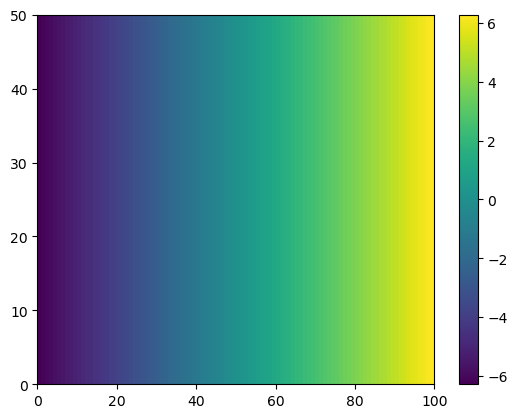

In [32]:
plt.pcolormesh(xx)
plt.colorbar()


### Applying conditionals to arrays

Sometime we want to identify values in an array that satisfy a given criterium. For example, we might wanna identify all negative numbers in an array


In [33]:
a = np.array([-1, 2, 3.2, -9, 10])

In [34]:
a < 0

array([ True, False, False,  True, False])

The conditional above returns an array of booleans. Surprisingly, we can use booleans as indices for an array.

In [35]:
idx = a < 0
print(idx)

[ True False False  True False]


In [36]:
a[idx]

array([-1., -9.])

the code above will select the elements of the array a only in places where the boolean variable idx is true (i.e., where the values are negative). We can also use booleans as indices directly (without saving in a separate variable)

In [37]:
a[a<0]

array([-1., -9.])

We can use this type of operation, for example, to clean up our data and manipulate it in all sorts of clever ways. For example, we might want to replace the negative values of the array by NaNs.

In [38]:
print('a before:', a)
a[a<0] = np.nan
print('a after:', a)

a before: [-1.   2.   3.2 -9.  10. ]
a after: [ nan  2.   3.2  nan 10. ]


Lets say we have an array of angles that we would like to convert from (0, 360) to (-180, 180)

In [39]:
angles = np.array([0., 45., 90., 135., 180., 225., 270., 315.])
print('angles before:', angles)
angles[angles>180] = angles[angles>180] - 360
print('angles after:', angles)

angles before: [  0.  45.  90. 135. 180. 225. 270. 315.]
angles after: [   0.   45.   90.  135.  180. -135.  -90.  -45.]



### Searching for a criterium

Numpy has a function where, which tells us the indices matching a given criterium. For example, we we want to find what are the indices where the values of angle are negative, we can do:


In [40]:
np.where(angles<0)

(array([5, 6, 7]),)

### Deep and shallow copy of arrays, and the `.copy()`

Important: this is a common source of bugs!
- View (shallow copy): Shares the same data underneath. Modifying one modifies the other. Typical sources: slicing, transpose .T, reshape (often), ravel() (when possible).
- Copy (deep copy of the array buffer): Owns its data; changes do not affect the original. 
- Use `.copy()` to break data sharing, ensure independence, avoid side-effects, and to safely pass arrays into code that may mutate them.

In [41]:
a = np.arange(9).reshape(3, 3)
v = a[:, 1:]     # slice → view

v[0, 0] = 999    # modifies the shared buffer
print("a after modifying v:\n", a)

a after modifying v:
 [[  0 999   2]
 [  3   4   5]
 [  6   7   8]]


In [42]:
def process_in_place(x):
    # Some library function you don't control that mutates input
    x -= x.mean()

a = np.arange(6, dtype=float)
v = a            # view
process_in_place(v)   # mutates 'a' too
print("a unexpectedly changed:", a)

# Safe approach:
a = np.arange(6, dtype=float)
v = a.copy()     # deep copy
process_in_place(v)   # a is safe
print("a preserved:", a)

a unexpectedly changed: [-2.5 -1.5 -0.5  0.5  1.5  2.5]
a preserved: [0. 1. 2. 3. 4. 5.]


### Clear notebook and commit changes

In the VSCode toolbar click on `Clear All Outputs`

Now, in the terminal, add you notebook to git, commit, and push to GitHub.

## Key points
- NumPy is the fundamental library for numerical computing in Python, providing support for arrays and mathematical operations.
- Array indexing in Python starts at 0 (not 1); access elements with `array[row, column]` syntax.
- Array slicing uses `start:end` notation where the end index is exclusive; omitting bounds defaults to the beginning or end of the array.
- NumPy functions like `np.mean()`, `np.max()`, `np.min()`, and `np.std()` perform operations on arrays; use the `axis` parameter to specify operations along rows (axis=0) or columns (axis=1).
- Comments in Python code start with `#` and are ignored by the interpreter; use them to explain code logic.
- You can create numpy array, and manipulate them using conditions.
- Know about deep and shallow copy of arrays and `.copy()`
- Version control your notebooks by clearing outputs before committing to keep git diffs clean and meaningful.